In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fenics import Function, plot
from utils.colors import CMAP
from utils.problem_setup import TestProblemsSetup
from time import time
from utils.utils import progress_bar, disk_cache

#from algorithms.dynamical_low_rank_solver import DynamicalLowRankSolver
from algorithms.cg_solvers import DynamicalLowRankCG, DynamicalLowRankApproximation
from algorithms.rsvd_solvers import MatrixFreeRSVD

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 13,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

PID = 'I'
N = 4_000
SETUP = TestProblemsSetup(n=int(np.sqrt(N)))
PARAMS = SETUP.problem_params[PID]
SEED = 15
RESULTS_FOLDER = '../../dlra_computational_time'

# Forward operator used in this notebook
pb = SETUP.get_single_problem(PID)
rsvd = MatrixFreeRSVD(pb['V_h'])
rsvd.solve(k=50)
w = rsvd.weights()

SOLVERS = {
    'DLRA': DynamicalLowRankApproximation,
    'DLRA-CG': DynamicalLowRankCG
}

def as_func(x, V_h):
    f = Function(V_h)
    f.vector()[:] = x
    return f

In [ ]:
lam = 1e-4
rtol = 0
mr = 1

param_grid = [
    {'solver': 'DLRA', 'name': 'adam',
    'args': {'method': 'adam',  'max_rank': mr, 'rtol': rtol, 'max_iter': 2_000}},
    #{'solver': 'DLRA', 'name': 'fixed',
    #'args': {'method': 'fixed', 'max_rank': mr, 'rtol': 1e-50, 'max_iter': 10_000, 'alpha': 2000}},
    {'solver': 'DLRA', 'name': 'steepest',
    'args': {'method': 'sd',    'max_rank': mr, 'rtol': rtol, 'max_iter': 2_000}},
    {'solver': 'DLRA-CG', 'name': 'DLRA-CG',
    'args': {'max_rank': mr, 'rtol': rtol, 'max_iter': 2_000, 'restart_every': None}},
    {'solver': 'DLRA-CG', 'name': 'rs-DLRA-CG',
    'args': {'max_rank': mr, 'rtol': rtol, 'max_iter': 2_000, 'restart_every': 10}}
]

In [133]:
@disk_cache(RESULTS_FOLDER)
def experiment(N_range, repeat, etol, param_grid, pid='I'):
    iterations = []
    results = []

    n_steps, step = repeat * len(param_grid) * len(N_range), 1
    for N in N_range:
        # Problem setup (mesh, rSVD, K, w)
        pb = TestProblemsSetup(n=int(np.sqrt(N))).get_single_problem(pid)
        rsvd = MatrixFreeRSVD(pb['V_h'])
        rsvd.solve(k=50, seed=SEED)
        w = rsvd.weights()

        for r in range(repeat):
            result = {'N': N}; iters = {'N': N}
            for params in param_grid:
                progress_bar(step, n_steps); step += 1

                # Solver setup
                name = params['name']
                solver = SOLVERS[params['solver']](rsvd, pb['x'])
                
                # All solver at given repeat use same X0 (starting point)
                t = time()
                solver.solve(pb['y'], w, lam, seed=SEED + r, etol=etol, verbose=False, **params['args'])
                result[name] = time() - t
                iters[name] = solver.niter

            results.append(result); iterations.append(iters)
    
    return pd.DataFrame(results), pd.DataFrame(iterations)

N_range = np.linspace(4000, 40_000, 19, dtype=int)
df, df_iter = experiment(N_range, repeat=100, etol=0.89, param_grid=param_grid, force=False)

[##############################] 7600/7600


In [143]:
df_iter

,N,adam,steepest,DLRA-CG,rs-DLRA-CG
0,4000,492,248,12,16
1,4000,493,258,12,16
2,4000,493,244,12,16
3,4000,493,288,12,16
4,4000,493,266,12,16
...,...,...,...,...,...
1895,40000,538,305,17,18
1896,40000,539,301,16,19
1897,40000,539,349,17,18
1898,40000,539,373,17,18


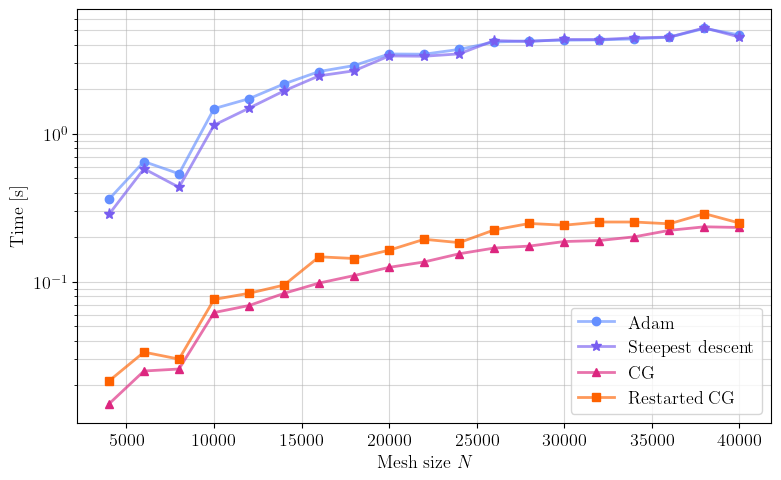

In [142]:
def plot_stats(stats, names=None, fig_name=None):
    from utils.colors import C5, M, MS
    from utils.plotting import save_plot
    from matplotlib.lines import Line2D

    fig, ax = plt.subplots(1, 1, figsize=(8, 5))

    for i, col in enumerate(stats.columns):
        ax.semilogy(stats.index, stats[col], lw=2.0, c=C5[i], alpha=.65)
        ax.semilogy(stats.index, stats[col], M[i], lw=2.0, ms=MS[i], c=C5[i])

    # Custom labels
    handles, labels = [], names
    for i in range(len(stats.columns)):
        legend_line = Line2D([0], [0], color=C5[i], linewidth=2.0, alpha=.65)
        legend_marker = Line2D([0], [0], color=C5[i], marker=M[i], markersize=MS[i], linestyle='None')
        handles.append((legend_line, legend_marker))

    ax.set_ylabel('Time [s]')
    ax.set_xlabel('Mesh size $N$')

    ax.grid(True, alpha=.5, which='both')
    ax.legend(handles=handles, labels=labels)
    plt.tight_layout()
    save_plot(fig_name)
    plt.show()


stats = df.groupby('N').agg('median')
plot_stats(stats, names=['Adam', 'Steepest descent', 'CG', 'Restarted CG'])

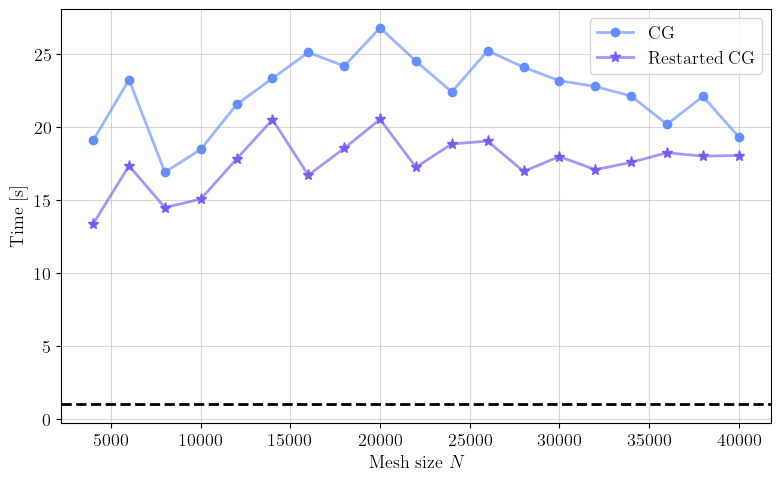

In [161]:
def plot_stats_rel(stats, names=None, fig_name=None):
    from utils.colors import C5, M, MS
    from utils.plotting import save_plot
    from matplotlib.lines import Line2D

    fig, ax = plt.subplots(1, 1, figsize=(8, 5))

    bl = stats['steepest']

    for i, col in enumerate(['DLRA-CG', 'rs-DLRA-CG']):
        ax.plot(stats.index, bl / stats[col],       lw=2.0, c=C5[i], alpha=.65)
        ax.plot(stats.index, bl / stats[col], M[i], lw=2.0, c=C5[i], ms=MS[i],)
    ax.axhline(1.0, c='black', lw=2.0, ls='--')

    # Custom labels
    handles, labels = [], names
    for i in range(len(names)):
        legend_line = Line2D([0], [0], color=C5[i], linewidth=2.0, alpha=.65)
        legend_marker = Line2D([0], [0], color=C5[i], marker=M[i], markersize=MS[i], linestyle='None')
        handles.append((legend_line, legend_marker))

    ax.set_ylabel('Time [s]')
    ax.set_xlabel('Mesh size $N$')

    ax.grid(True, alpha=.5, which='both')
    ax.legend(handles=handles, labels=labels)
    plt.tight_layout()
    save_plot(fig_name)
    plt.show()


plot_stats_rel(stats, names=['CG', 'Restarted CG'])

In [130]:
errors = []
solutions = []

etol = 0.89
for params in param_grid:
    solver = SOLVERS[params['solver']](rsvd, pb['x'])
    args = params['args']
    x = solver.solve(pb['y'], w, lam, seed=SEED, etol=etol, **args)

    solutions.append(x)
    errors.append(solver.error.copy())

Converged at iter 494 [etol criteria: rel_res=0.89]
Converged at iter 280 [etol criteria: rel_res=0.89]
Converged at iter 12 [etol criteria: rel_res=0.887]
Converged at iter 15 [etol criteria: rel_res=0.889]


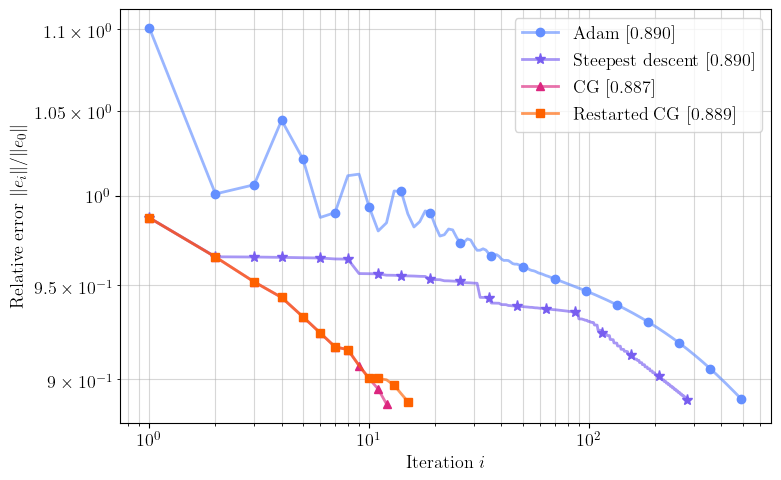

In [131]:
def plot_errors(e_list, names=None, fig_name=None):
    from utils.colors import C5, M, MS
    from utils.plotting import save_plot
    from matplotlib.lines import Line2D

    fig, ax = plt.subplots(1, 1, figsize=(8, 5))

    if names is None:
        names = ['' for _ in e_list]

    for i, e in enumerate(e_list):
        x = np.arange(1, len(e) + 1)

        # Makers with log-space position
        n_marks = 20
        x_marks = np.logspace(np.log10(x[0]), np.log10(x[-1]), n_marks)
        mark_idx = np.unique([np.abs(x - xm).argmin() for xm in x_marks])

        ax.loglog(x, e, lw=2.0, label=names[i], markevery=mark_idx, c=C5[i], alpha=.65)
        ax.loglog(x, e, M[i], lw=2.0, markevery=mark_idx, ms=MS[i], c=C5[i])


    # Custom labels
    handles, labels = [], names
    for i in range(len(e_list)):
        legend_line = Line2D([0], [0], color=C5[i], linewidth=2.0, alpha=.65)
        legend_marker = Line2D([0], [0], color=C5[i], marker=M[i], markersize=MS[i], linestyle='None')
        handles.append((legend_line, legend_marker))

    #ax.axhline(0.86, ls='--', lw=2.0, c='r')
    ax.set_ylabel('Relative error $\| e_i \| / \| e_0 \|$')
    ax.set_xlabel('Iteration $i$')

    labels = []
    for name, e in zip(names, e_list):
        labels.append(f"{name} [{np.min(e):.3f}]")
    
    ax.grid(True, which='both', alpha=.5)
    ax.legend(handles=handles, labels=labels)
    plt.tight_layout()
    save_plot(fig_name)
    plt.show()


names = ['Adam', 'Steepest descent', 'CG', 'Restarted CG']
plot_errors(errors, names=names)

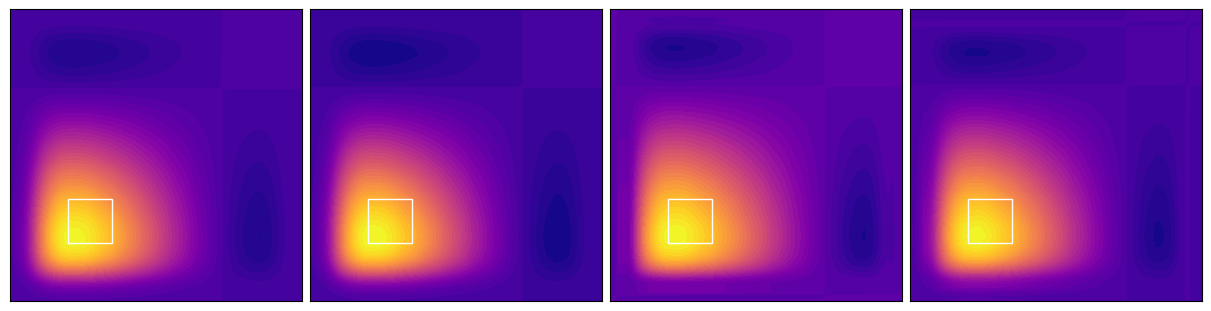

In [132]:
def plot_multiple_f(f_list, params=None, names=None, fig_name=None, shrink=0.3):
    from utils.colors import CMAP
    from utils.plotting import save_plot
    import matplotlib.patches as patches

    width, height = PARAMS['width'], PARAMS['height']
    x0s, y0s = PARAMS['x0'], PARAMS['y0']

    fig, axes = plt.subplots(1, len(f_list), figsize=(12, 12 / len(f_list)), constrained_layout=True)

    if names is None:
        names = ['' for _ in axes.flat]

    for ax, func, name in zip(axes.flat, f_list, names):
        plt.sca(ax)
        #vmin = np.min(func.vector().get_local())

        p = plot(func, title=name, cmap=CMAP)
        #fig.colorbar(p, ax=ax, format="%.2f", shrink=shrink)
        ax.set_xticks([])
        ax.set_yticks([])

        for x0, y0 in zip(x0s, y0s):
            square = patches.Rectangle(
                (x0, y0), width, height,
                edgecolor="white",
                facecolor="none"
            )
            ax.add_patch(square)

    save_plot(fig_name=fig_name)
    plt.show()

plot_multiple_f([as_func(x, pb['V_h']) for x in solutions])